In [13]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize


# 1. Define the grid domain (matching the U[-3, 3] bounds)
x_vals = np.linspace(0.1, 3, 100)
y_vals = np.linspace(0.1, 3, 100)
X, Y = np.meshgrid(x_vals, y_vals)
x = np.array([X, Y])

def myplot(Z, title = "3D Plot of the Symbolic Expression", max_z=None):
  # 3. Create the 3D plot
  fig = plt.figure(figsize=(10, 7))
  ax = fig.add_subplot(111, projection='3d')

  # Plot the surface with a visually distinct colormap
  surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.9)

  # 4. Labels and Styling
  ax.set_title(title, fontsize=14, pad=20)
  ax.set_xlabel('$x_0$', fontsize=12)
  ax.set_ylabel('$x_1$', fontsize=12)
  ax.set_zlabel('$z$', fontsize=12)
  if max_z is not None:
    ax.set_zlim(bottom=Z.min(), top=max_z)

  # Add a color bar which maps values to colors
  fig.colorbar(surf, ax=ax, shrink=0.1, aspect=10, label='Z Value')

  # Adjust the initial viewing angle for clarity
  ax.view_init(elev=30, azim=-120)

  plt.tight_layout()
  plt.show()

In [14]:
import numpy as np
from matplotlib.colors import Normalize
from matplotlib import cm

def myplot2(Z1:np.array, title1:str, *args: tuple[np.array, str, dict[str,float]|None], max_z: str|float|int|None=None):
  """:param Z1: 3D numpy array
     :param args: A tuple of (Zi, title_i, metrics_i) for additional plots
     """
  num_plots = 1 + len(args)

  all_Z_values = [Z1] + [Zi for Zi, _, _ in args] # Unpack args for Z values

  # Filter out arrays that are entirely NaN before calculating min/max
  valid_Z_arrays = [Z_arr for Z_arr in all_Z_values if not np.all(np.isnan(Z_arr))]

  if not valid_Z_arrays: # If all Z arrays are entirely NaN
      global_min = -1 # arbitrary defaults if no valid data
      global_max = 1
  else:
      global_min = np.min([np.nanmin(Z_arr) for Z_arr in valid_Z_arrays])
      global_max = np.max([np.nanmax(Z_arr) for Z_arr in valid_Z_arrays])

  norm = Normalize(vmin=global_min, vmax=global_max) if max_z == 'identical' else None
  cmap = cm.viridis  # Choose your preferred colormap

  fig, axs = plt.subplots(1, num_plots, figsize=(6 * num_plots, 7), subplot_kw={'projection': '3d'})

  # Ensure axs is iterable even for a single plot
  if num_plots == 1:
      axs = [axs]

  # First subplot for Z1 (Original Function)
  ax1=axs[0]
  if not np.all(np.isnan(Z1)): # Only plot if Z1 is not entirely NaN
      surf1 = ax1.plot_surface(X, Y, Z1, cmap=cmap, norm=norm, edgecolor='none', alpha=0.9)
      if max_z != 'identical' or len(args)==0:
        fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label='Z Value')
  else:
      ax1.text2D(0.5, 0.5, "Data Not Available", transform=ax1.transAxes, ha="center")
  ax1.set_title(title1, fontsize=14, pad=20)
  ax1.set_xlabel('$x_0$', fontsize=12)
  ax1.set_ylabel('$x_1$', fontsize=12)
  ax1.set_zlabel('$z$', fontsize=12)
  ax1.view_init(elev=30, azim=-120)
  if max_z == 'identical':
    ax1.set_zlim(bottom=global_min, top=global_max)
  elif isinstance(max_z, (float, int)):
    ax1.set_zlim(top=max_z)

  # Subsequent subplots for args (Approximations)
  for i, (Zi, title, metrics_i) in enumerate(args):
    ax_i = axs[i+1]
    if not np.all(np.isnan(Zi)): # Only plot if Zi is not entirely NaN
        surf_i = ax_i.plot_surface(X, Y, Zi, cmap=cmap, norm=norm, edgecolor='none', alpha=0.9)
        if max_z != 'identical':
          fig.colorbar(surf_i, shrink=0.5, aspect=10, label='Z Value')
        elif i==len(args)-1:
          # This part assumes a single color bar for 'identical' max_z mode
          cbar_ax = fig.add_axes([1, 0.15, 0.025, 0.7]) # Adjust position as needed
          fig.colorbar(surf_i, cax=cbar_ax, orientation='vertical', shrink=0.5, aspect=10, label='Z Value')
    else:
        ax_i.text2D(0.5, 0.5, "Data Not Available", transform=ax_i.transAxes, ha="center")

    ax_i.set_title(title, fontsize=14, pad=20)
    ax_i.set_xlabel('$x_0$', fontsize=12)
    ax_i.set_ylabel('$x_1$', fontsize=12)
    ax_i.set_zlabel('$z$', fontsize=12)
    ax_i.view_init(elev=30, azim=-120)
    if max_z == 'identical':
      ax_i.set_zlim(bottom=global_min, top=global_max)
    elif isinstance(max_z, (float, int)):
      ax_i.set_zlim(top=max_z)

    # Add textbox for metrics_i if provided
    if metrics_i is not None:
        text_str = """Complexity: {complexity:.2f}\nRMSE: {test_rmse:.4f}\nTrees: {trees}""".format(**metrics_i)
                      # Beta: {beta:.2f}
                      # Proposals: {proposals}
                      # Max Comp: {max_complexity}
                      #

        ax_i.text2D(0.05, 0.95, text_str, transform=ax_i.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.5))

  plt.tight_layout()
  plt.show()


In [15]:
Re = np.real
# Define a small epsilon to prevent log(0) or log(negative numbers)
epsilon = 1e-10
# Redefine log to ensure its argument is always positive
log = lambda x: np.log(np.maximum(x, epsilon))
# Define a maximum value for exp input to prevent overflow
exp_max_arg = 27.63
# Redefine exp to clip its argument and prevent overflow
exp = lambda x: np.exp(np.clip(x, a_min=None, a_max=exp_max_arg))

Benchmark functions

In [16]:
f = [2.5 *x[0]**4 - 1.3 *x[0]**3 + 0.5*x[1]**2 - 1.7*x[1],
      8*x[0]**2 + 8*x[1]**3 - 15,
     0.2*x[0]**3 + 0.5*x[1]**3 - 1.2*x[1] - 0.5*x[0],
     1.5 * np.exp(x[0])+5 *np.cos(x[1]),
     6*np.sin(x[0])*np.cos(x[1]),
     1.35*x[0]*x[1] +5.5*np.sin((x[0]-1.0)*(x[1]-1.0))
     ]

f = {i+1: f[i] for i in range(len(f))}

f_test  = {'eml_test1':x[ 0] ** 2,
           'eml_test2':  x[ 0] ** 3,
           'eml_test3': x[0] ** 2 + x[1] ** 2 + x[0] * x[1],
           'eml_test4': np.cos(x[0]) + np.sin(x[1]),
           'xy': x[0]*x[1]}

f = {**f, **f_test}

### Extracting Simplified Expressions from File

Parsing `simplified_expressions_str` dictionary

In [17]:
import pandas as pd
import numpy as np # Import numpy for abs and array operations

def extract_expressions_and_metrics(file: str, verbose: bool=True, tolerance=1e-6) -> tuple[dict[int|str, str], dict[int|str, str], dict[int|str, dict[str, float]]]:
  df_metrics = pd.read_csv(file)

  extracted_full_expressions = {}
  extracted_simplified_expressions = {}
  extracted_metrics = {}

  for index, row in df_metrics.iterrows():
      func_name_raw = row['formula'].strip()
      simplified_expr = row['simplified_expression'].strip()
      full_expr = row['final_expression'].strip() # Extract full expression
      complexity = row['complexity']
      test_rmse = row['test_rmse']
      beta = row['beta']
      proposals = row['proposals']
      max_complexity = row['max_complexity']

      # Extract and process coefficients to count 'trees'
      coefficients_str = row['coefficients']
      try:
          coeffs = np.array(eval(coefficients_str))
          trees = np.sum(np.abs(coeffs[1:]) > tolerance) if len(coeffs) > 1 else 0
      except Exception as e:
          print(f"Warning: Could not parse coefficients for {func_name_raw}: {e}. Setting trees to NaN.")
          trees = np.nan

      # Determine the key for the dictionaries (int for f1, f2, etc., 'xy' for xy)
      if func_name_raw.startswith('f'):
        key_str = func_name_raw[1:]
        if key_str.isdigit():
            key = int(key_str)
        elif key_str.startswith('_'):
            key = key_str[1:]
        else:
            key = key_str
      else:
          print(f"Warning: Unknown function name format: {func_name_raw}. Skipping.")
          continue

      extracted_full_expressions[key] = full_expr # Store full expression
      extracted_simplified_expressions[key] = simplified_expr
      extracted_metrics[key] = {
          'complexity': complexity,
          'test_rmse': test_rmse,
          'beta': beta,
          'proposals': proposals,
          'max_complexity': max_complexity,
          'trees': trees
      }

  if verbose:
    print("Extracted full expressions:")
    for key, value in extracted_full_expressions.items():
        print(f"{key}: {value[:100]}...") # Print first 100 chars to avoid long output

    print("Extracted simplified expressions:")
    for key, value in extracted_simplified_expressions.items():
        print(f"{key}: {value[:100]}...") # Print first 100 chars to avoid long output

    print("\nExtracted metrics:")
    for key, value in extracted_metrics.items():
        print(f"{key}: Complexity={value['complexity']}, Test RMSE={value['test_rmse']}, Beta={value['beta']}, Proposals={value['proposals']}, Max Complexity={value['max_complexity']}, Trees={value['trees']}\n")

  return extracted_full_expressions, extracted_simplified_expressions, extracted_metrics

### Plotting discovered EML approximations
It should be noticed, that despite nice fitting score (RMSE) some central plots look kind of detached from the original surface, even when bloated trees are discarded (in case their coefficients fitted by OLS $<1e-6$). This can be theoretically attributed to the offset incorparated in first coefficient ($\beta_0$) and, probably, the remaining trees.

/tmp/ipykernel_24715/521904626.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


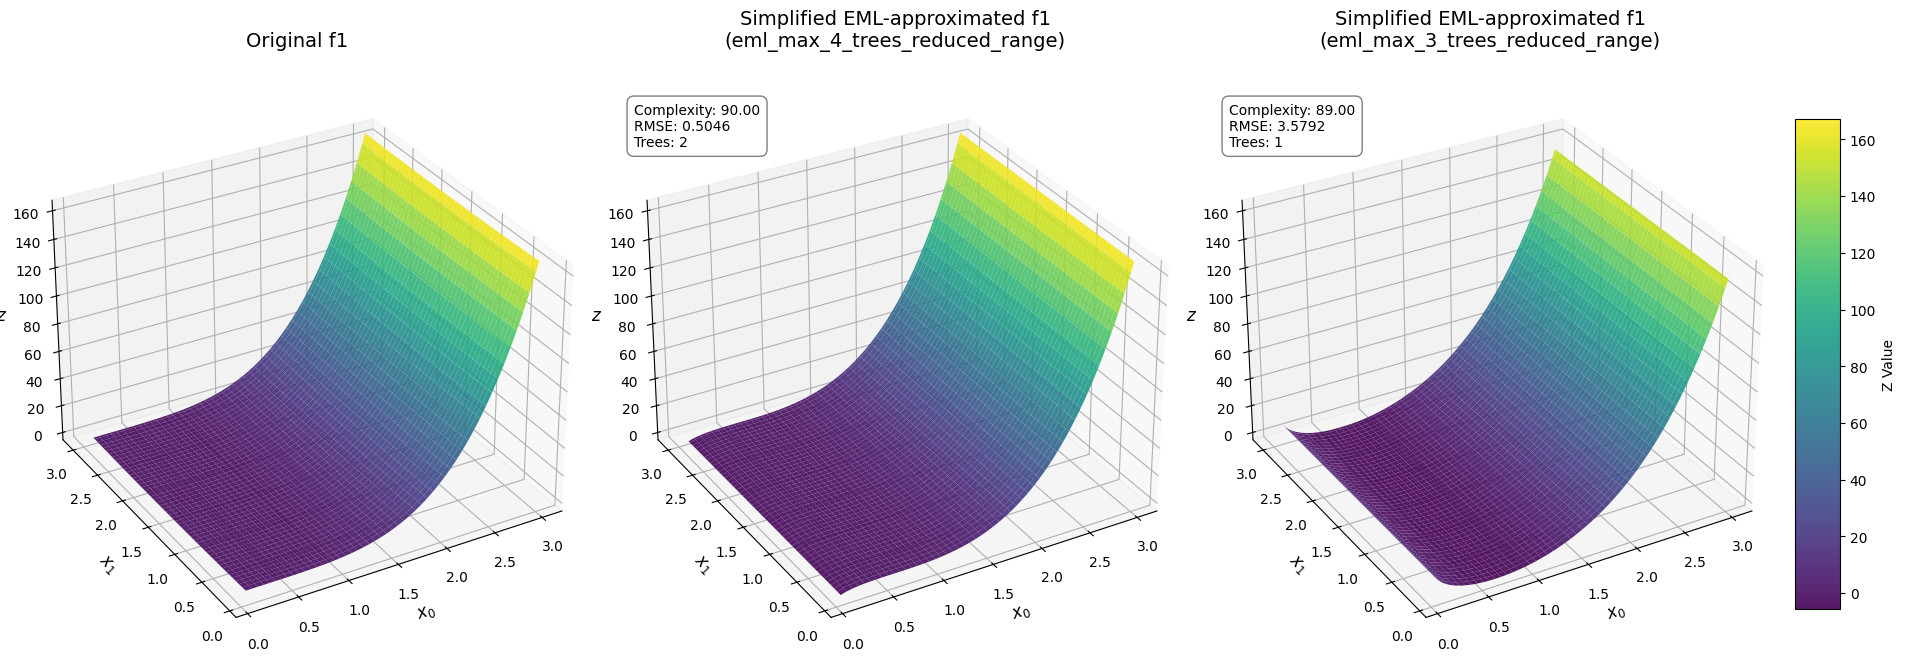

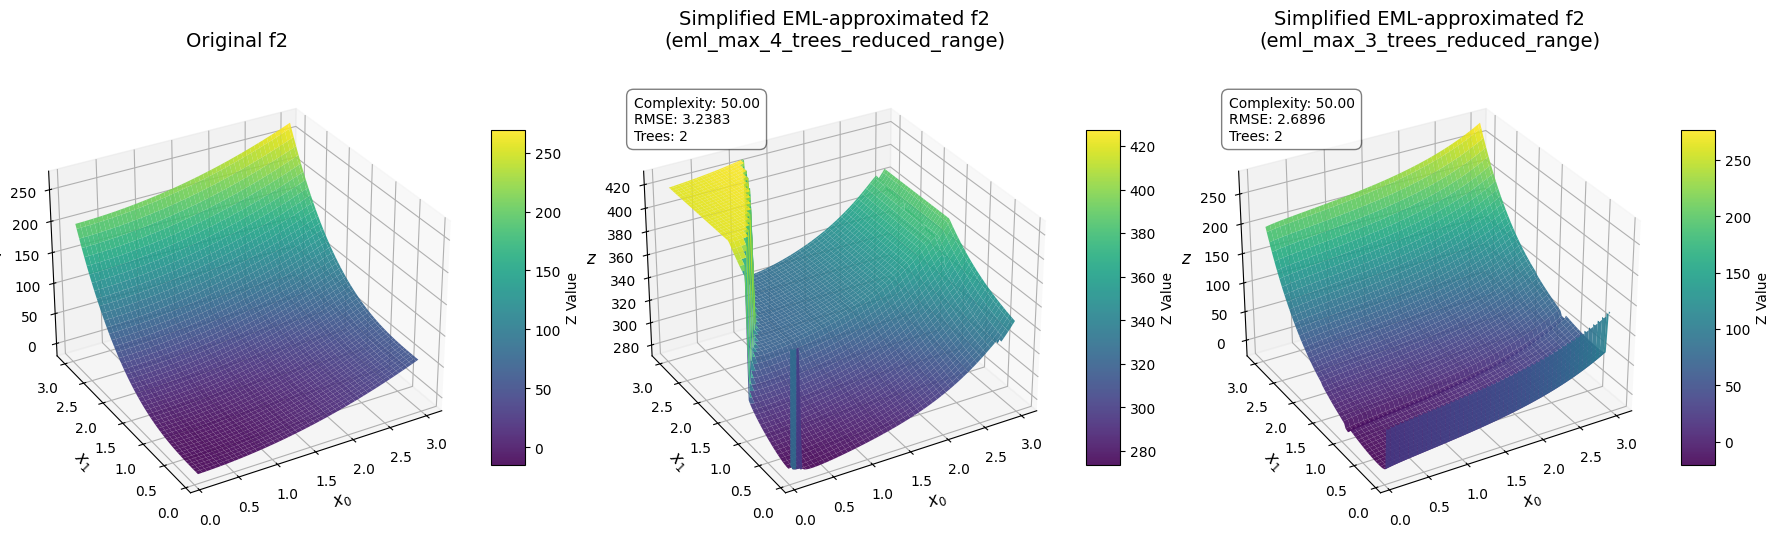

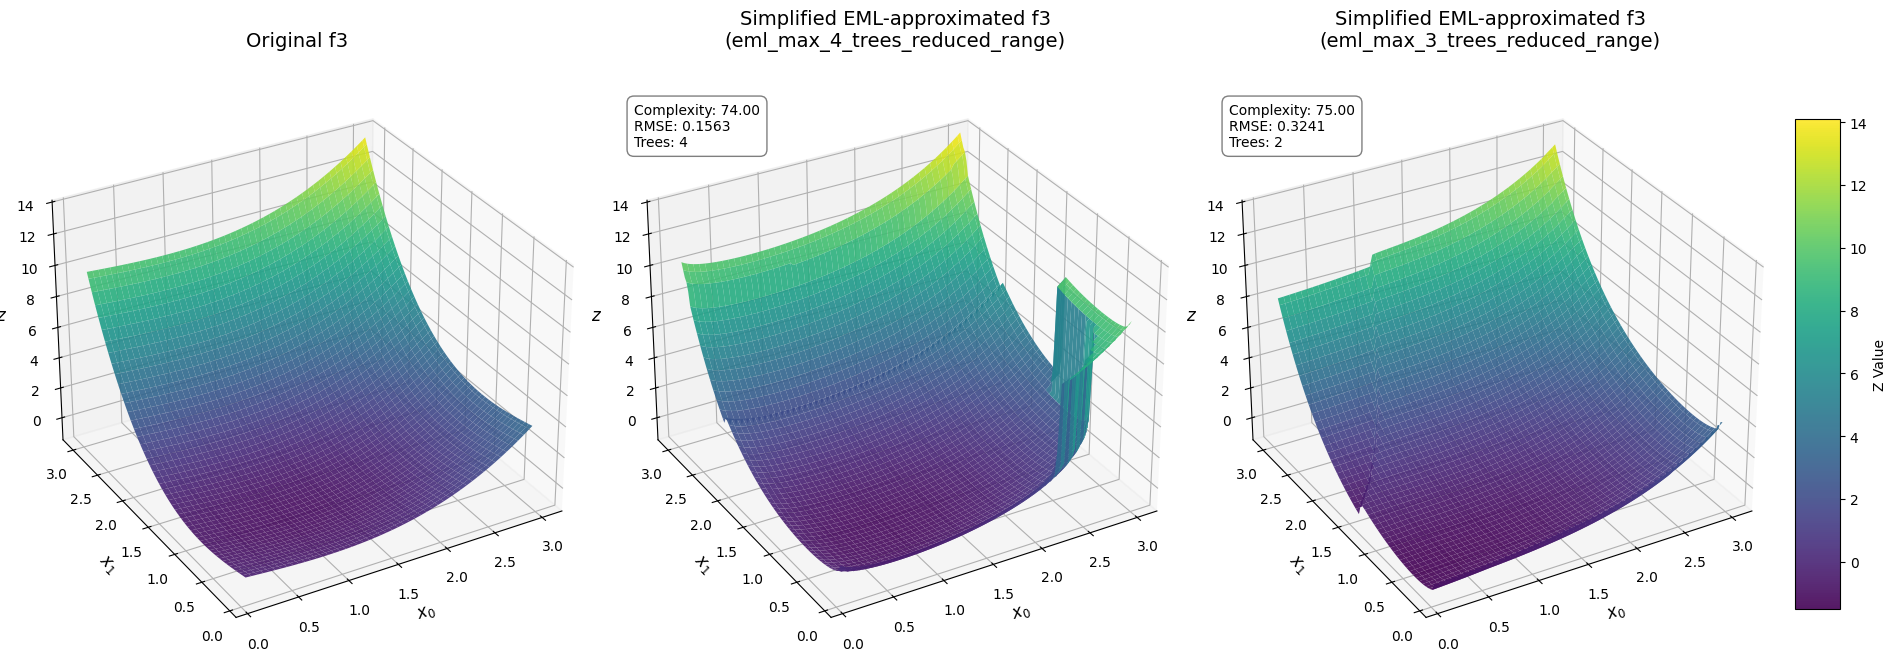

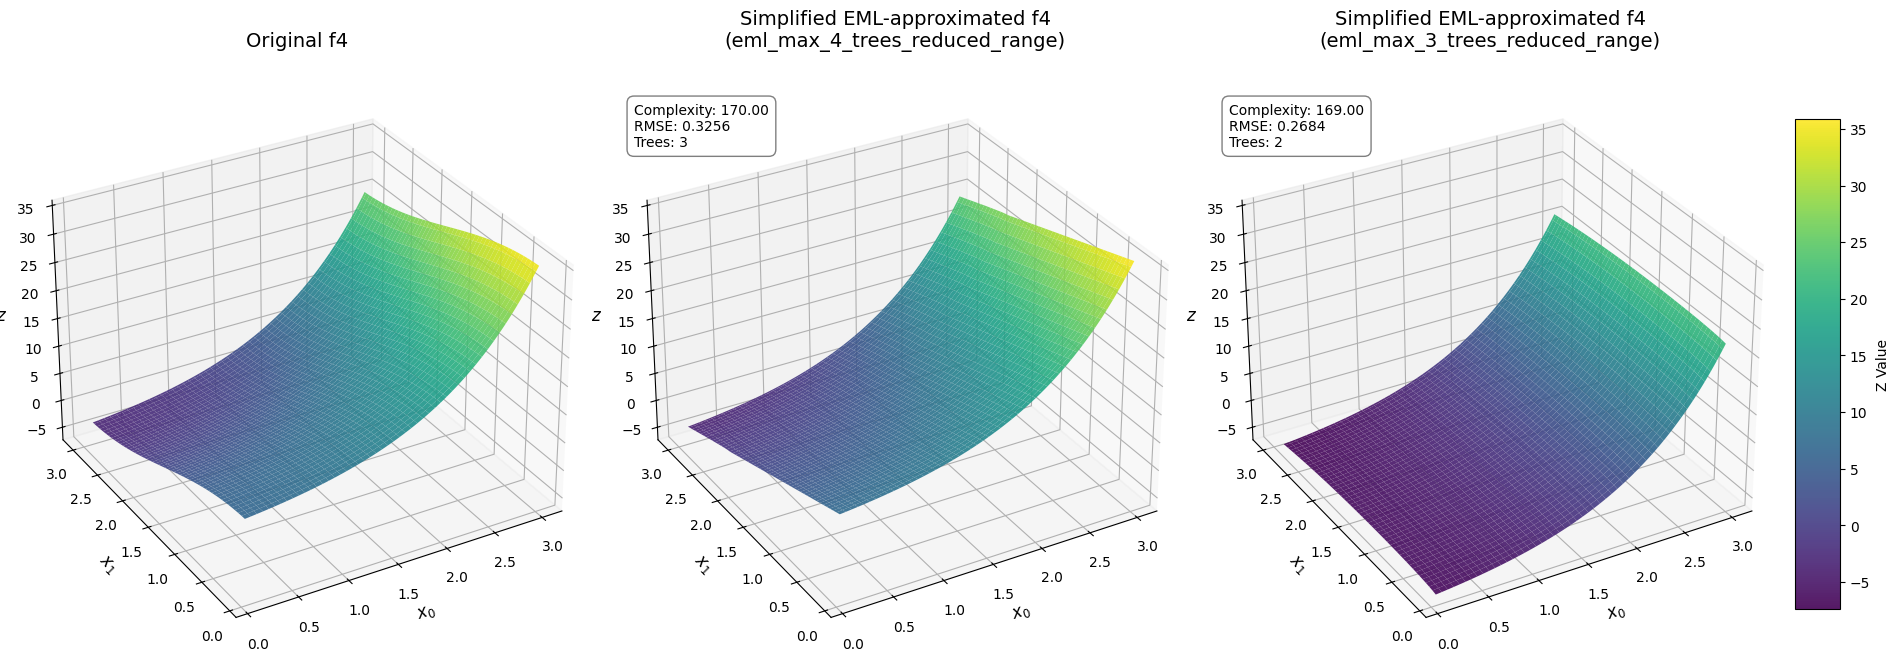

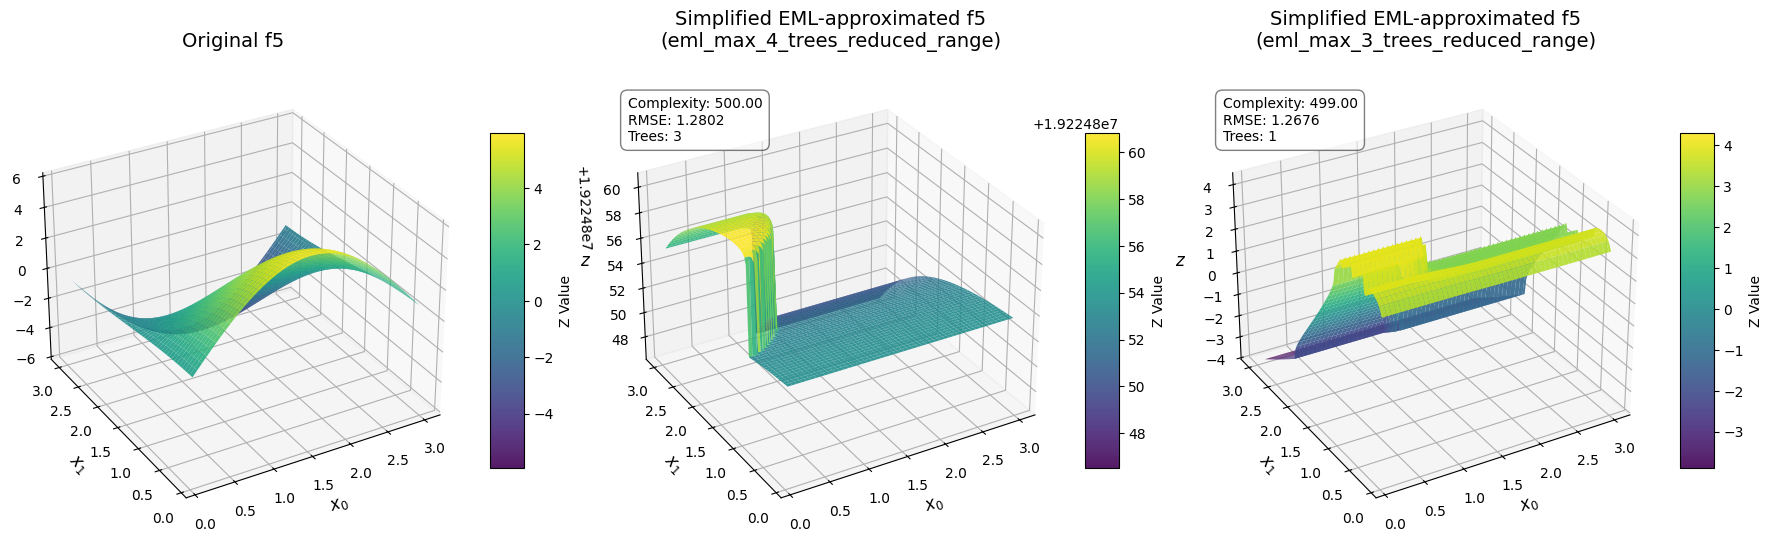

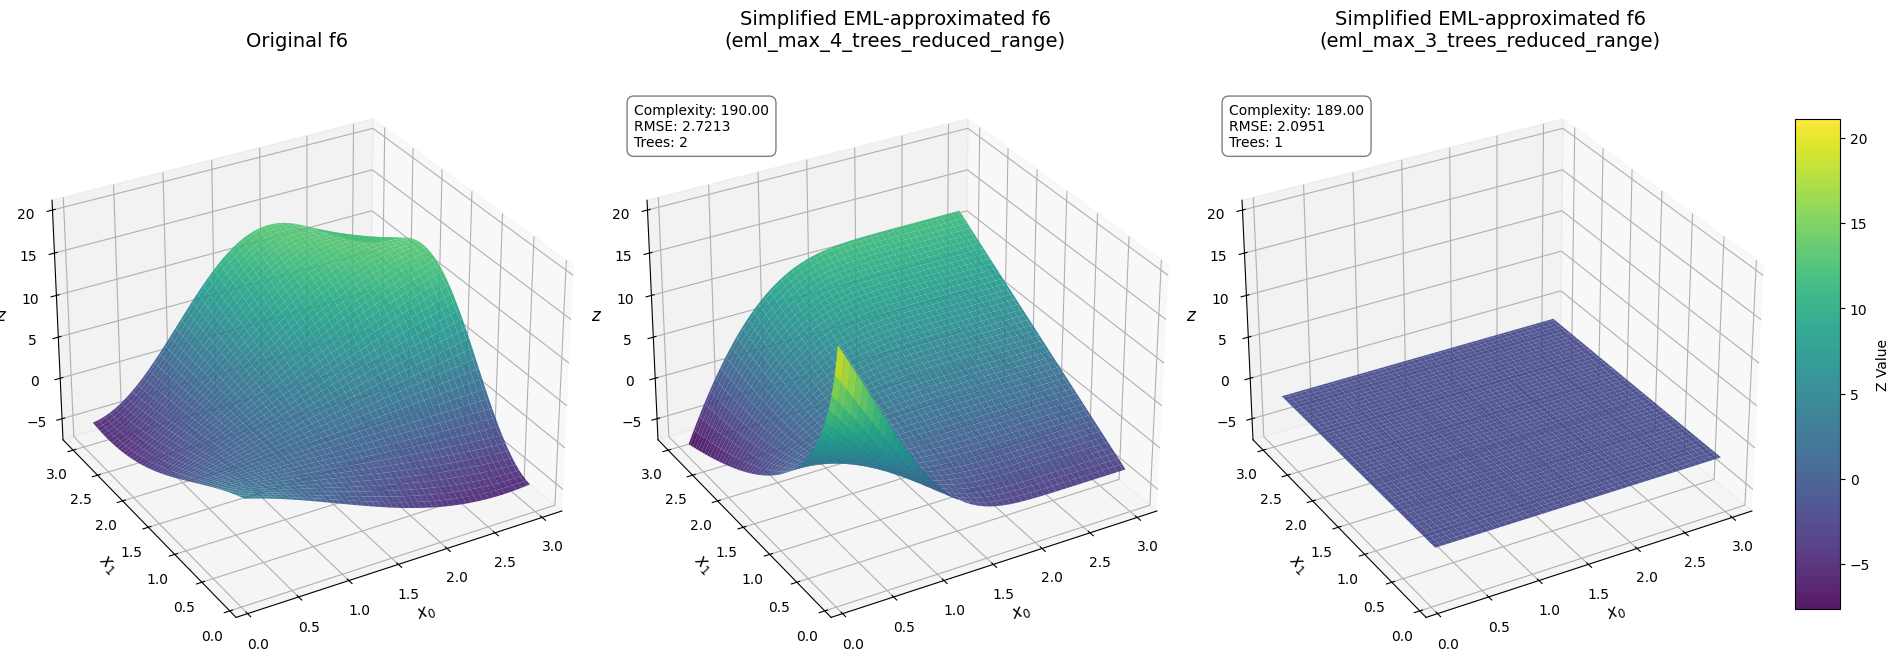

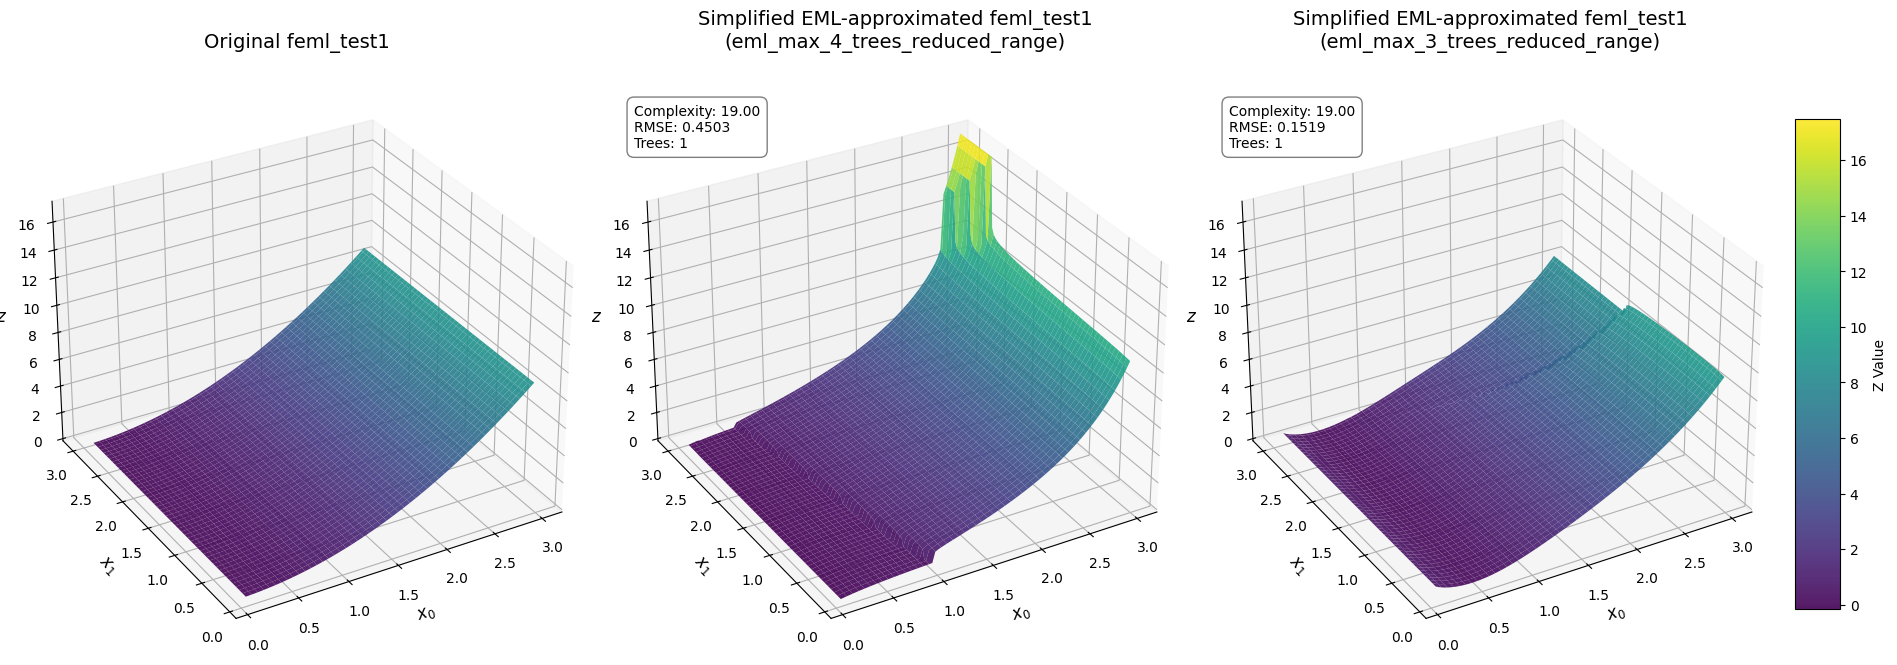

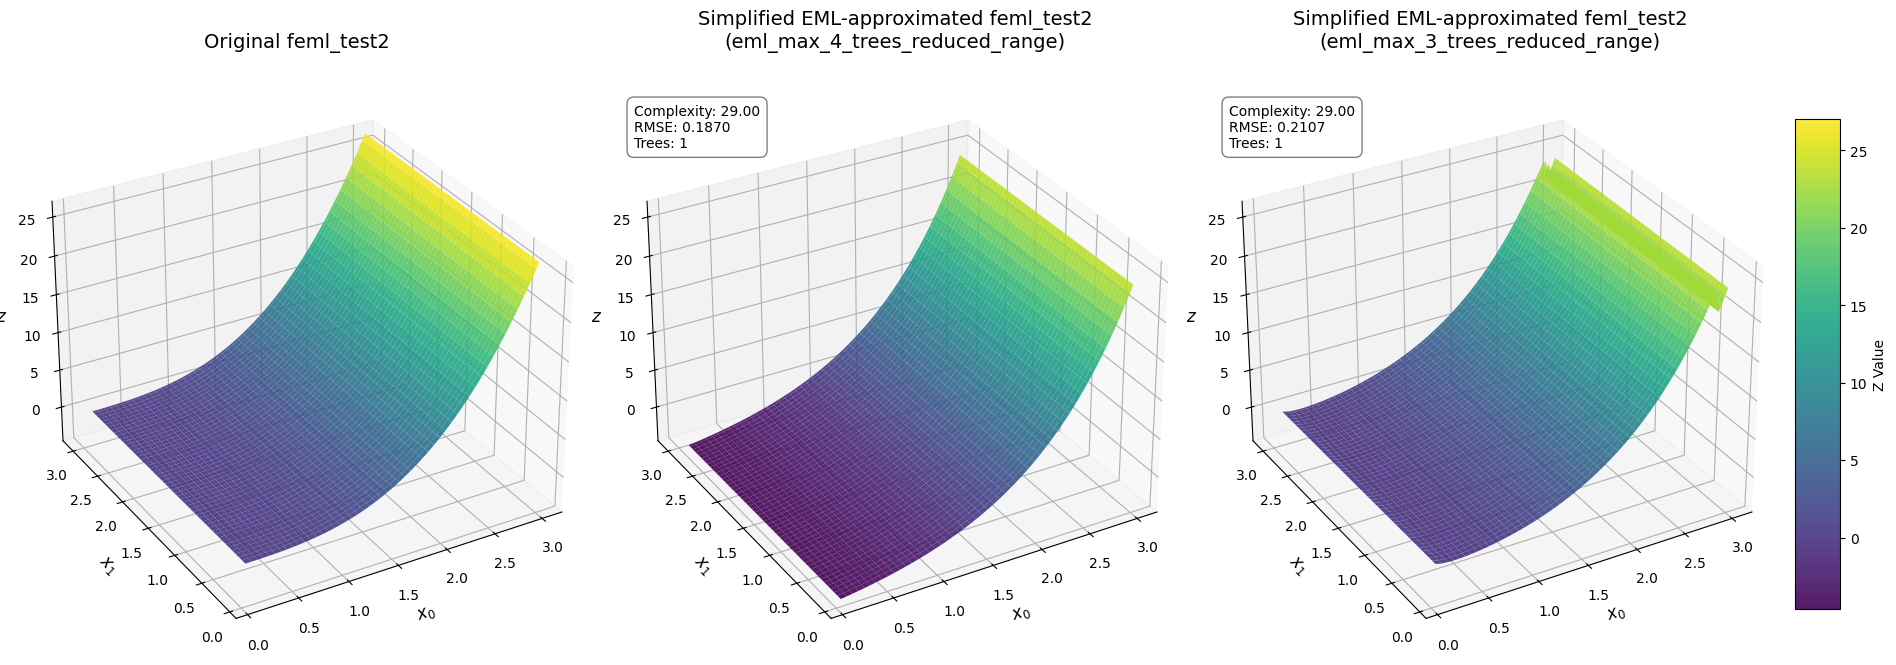

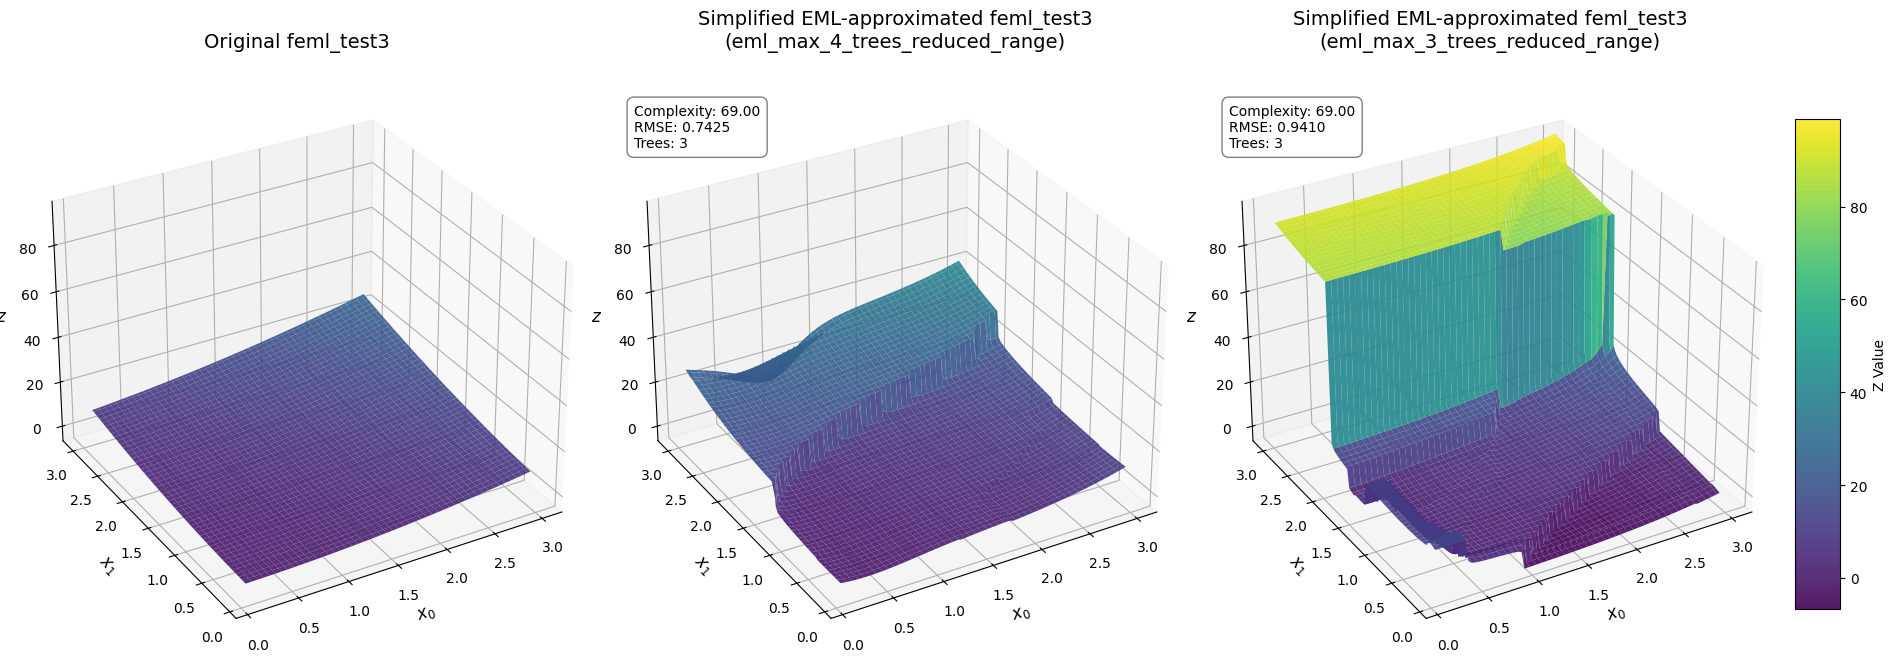

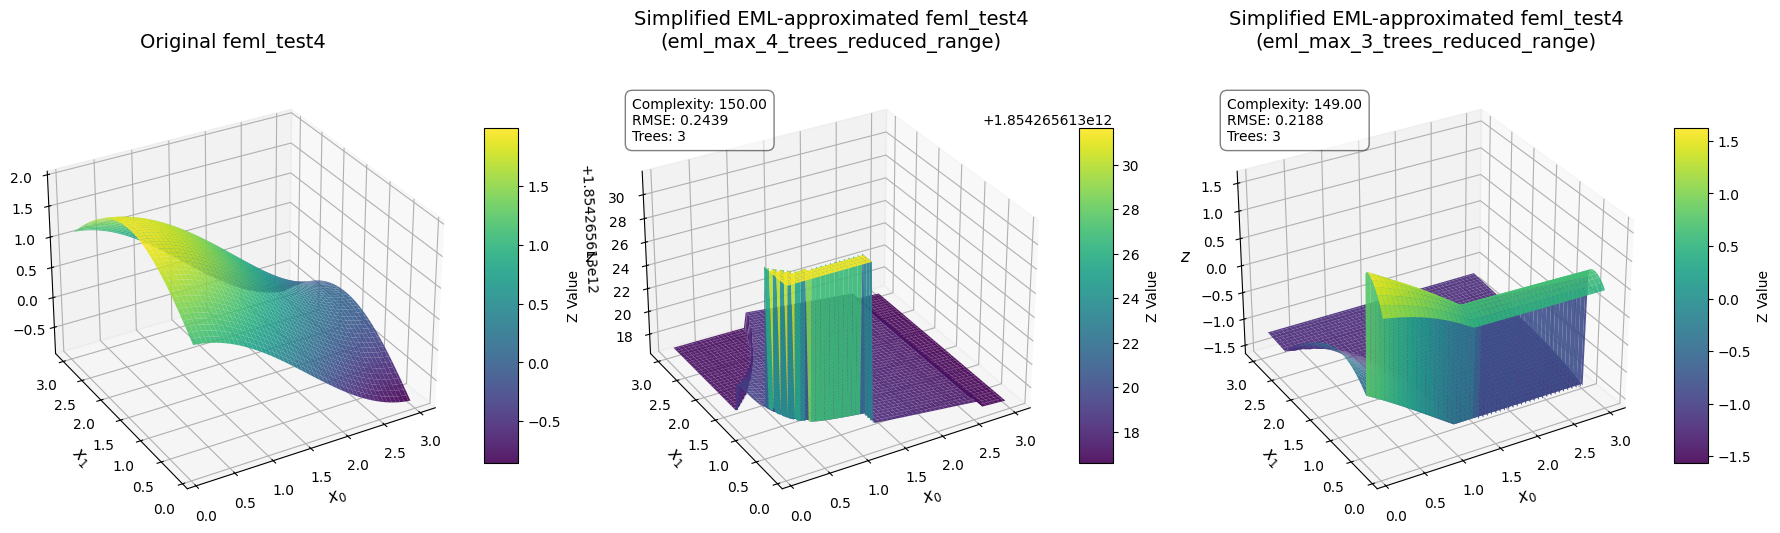

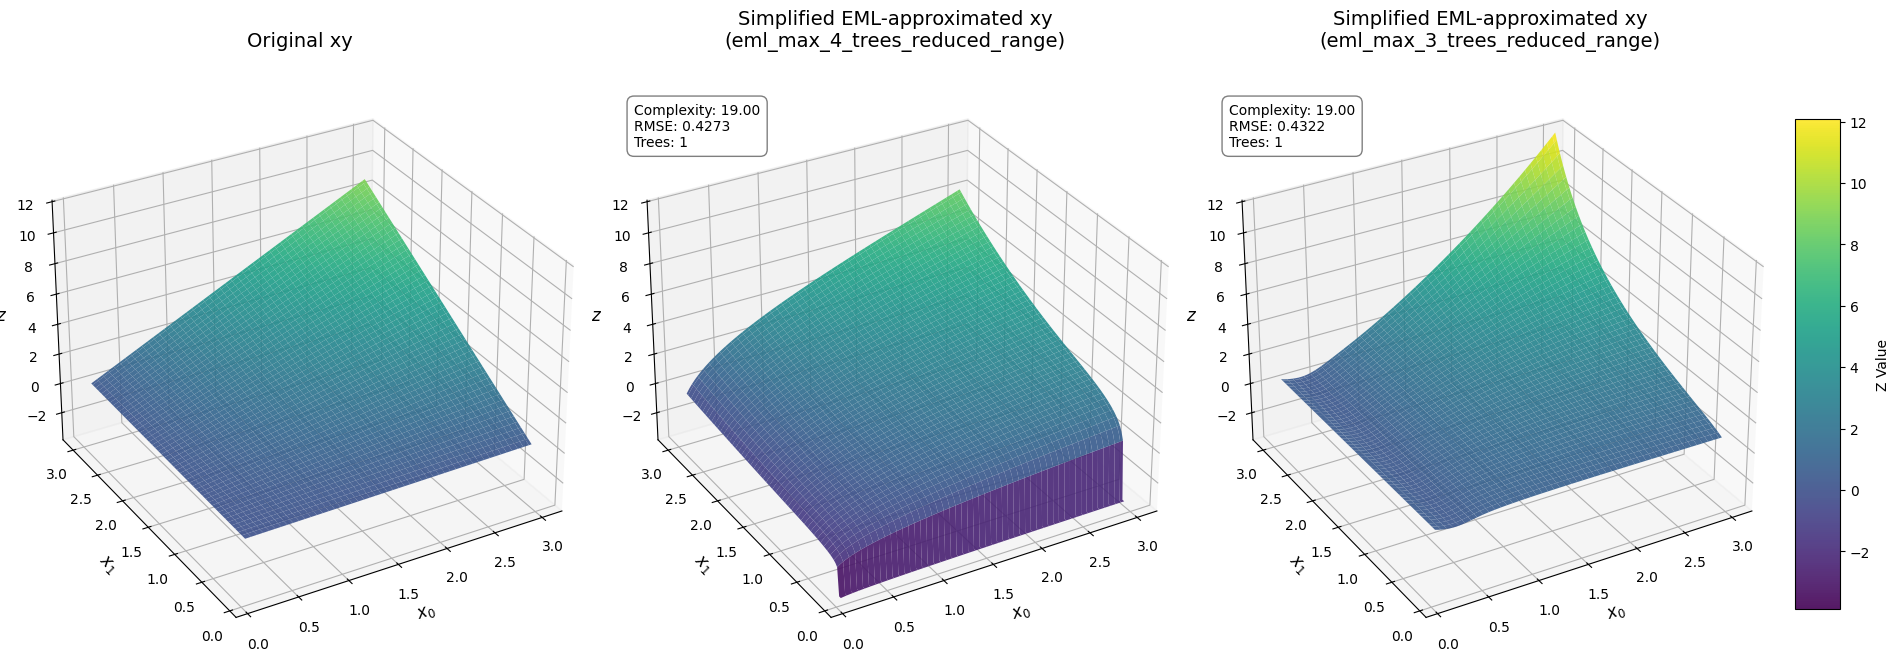

In [19]:
import numpy as np
def aggregate_plots(f: dict[int|str, np.ndarray], files: list[str], use_full_expression: bool = False,
                    options: dict[int|str, dict[str, float|str]] = {}):
    all_simplified_data = {} # Stores {file_identifier: {'simplified_expressions_str': {...}, 'extracted_metrics': {...}}}

    # Step 1: Extract data for each file
    for file_path in files:
        file_identifier = file_path.split('/')[-1].replace('.csv', '') # Simple way to get a unique name for titles, remove .csv
        # Use verbose=False to prevent repeated print statements for each file
        extracted_full_expressions_single_file, extracted_simplified_expressions_single_file, extracted_metrics_single_file = \
            extract_expressions_and_metrics(file_path, verbose=False)

        all_simplified_data[file_identifier] = {
            'full_expressions_str': extracted_full_expressions_single_file,
            'simplified_expressions_str': extracted_simplified_expressions_single_file,
            'extracted_metrics': extracted_metrics_single_file
        }

    # Step 2: Identify all unique function keys across all files
    all_function_keys = set()
    for file_data in all_simplified_data.values():
        all_function_keys.update(file_data['simplified_expressions_str'].keys())

    # Step 3: For each original function, plot it alongside all its approximations from different files
    for key in sorted(all_function_keys, key=lambda x: str(x)): # Sort keys for consistent plotting order
        # Ensure the key exists in the original functions 'f'
        if key not in f:
            print(f"Warning: Original function f{key} not found in 'f' dictionary. Skipping plotting for this key.")
            continue

        myplot2_args = [] # List to store (Z_value, title, metrics) for approximations

        for file_identifier, file_data in all_simplified_data.items():
            if use_full_expression:
                expr_str = file_data['full_expressions_str'].get(key)
                expression_type = "Full"
            else:
                expr_str = file_data['simplified_expressions_str'].get(key)
                expression_type = "Simplified"

            if expr_str:
                processed_expr_str = expr_str.replace('x[0]', 'X').replace('x[1]', 'Y')
                try:
                    Z_simplified_for_file = eval(processed_expr_str)

                    metrics_for_plot = None
                    if key in file_data['extracted_metrics']:
                        metrics_for_plot = file_data['extracted_metrics'][key]

                    if key == 'xy':
                        approximation_title = f"{expression_type} EML-approximated {key}\n({file_identifier})"
                    else:
                        approximation_title = f"{expression_type} EML-approximated f{key}\n({file_identifier})"

                    myplot2_args.append((Z_simplified_for_file, approximation_title, metrics_for_plot))
                except Exception as e:
                    print(f"Error evaluating {expression_type} expression for f{key} from {file_identifier}: {e}")

        if myplot2_args: # Only call myplot2 if there are valid approximations to show
            original_function_title = f"Original f{key} " if key != 'xy' else f"Original {key}"
            # max_z='identical' ensures all plots in the row have the same z-axis scale
            myplot2(f[key], original_function_title,  *myplot2_args
                    , max_z='identical' if key not in options else options[key]['max_z']
                    )
        else:
            print(f"No valid {expression_type.lower()} approximations found for f{key} across the provided files. Skipping plot.")

# Call aggregate_plots with the actual and dummy CSV files
aggregate_plots(f, ['eml_max_4_trees_reduced_range.csv', 'eml_max_3_trees_reduced_range.csv'],
                # use_full_expression=True,
                options = {2: {'max_z':None}, 5: {'max_z': None}, 'eml_test4': {'max_z': None}}
                )

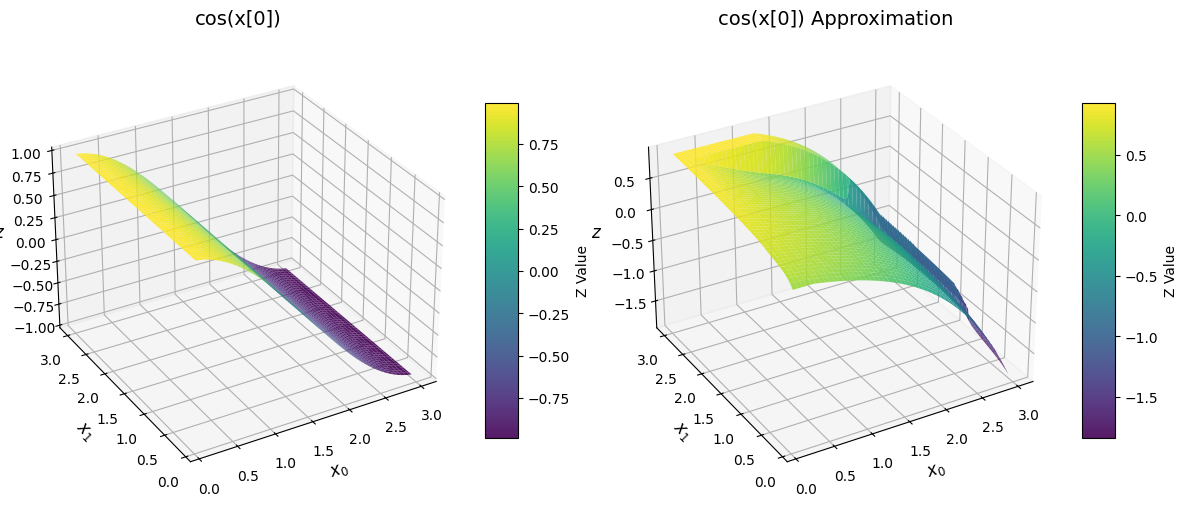

In [20]:
Z = 0.788351 - 0.128483*(Re(exp(exp(1)-log(exp(exp(1)-log(exp(x[0])-log(exp(1)-log(exp(x[1])-log(exp(exp(x[1])-log(exp(exp(exp(x[0])-log(exp(exp(x[0])-log(exp(x[1])-log(exp(exp(1)-log(exp(exp(1)-log(exp(x[1])-log(exp(1)-log(exp(1)-log(exp(1)-log(exp(x[0])-log(exp(1)-log(x[1]))))))))-log(x[1])))-log(x[0]))))-log(x[0])))-log(exp(x[1])-log(exp(exp(x[1])-log(exp(x[1])-log(1)))-log(1))))-log(x[1])))-log(x[1]))))))-log(1)))-log(x[1])))


myplot2(np.cos(x[0]), "cos(x[0])", (Z, "cos(x[0]) Approximation", None))